In [8]:
# Basado en: https://towardsdatascience.com/saliency-map-using-pytorch-68270fe45e80
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from torchsummary import summary
import requests
from PIL import Image
from google.colab import drive

# Usamos VGG-19 pre-entrenado para clasificación de imágenes

model = torchvision.models.vgg19(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

In [9]:
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [10]:

def download(url,fname):
    response = requests.get(url)
    with open(fname,"wb") as f:
        f.write(response.content)

# Descarga la imagen
download("https://specials-images.forbesimg.com/imageserve/5db4c7b464b49a0007e9dfac/960x0.jpg?fit=scale","input.jpg")

# Abre la imagen
img = Image.open('input.jpg')

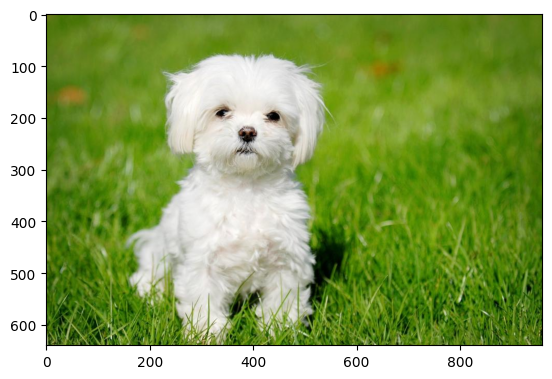

In [11]:
plt.imshow(img)

In [12]:
# Preprocesa la imagen (normaliza y crea el batch)
def preprocess(image, size=224):
    transform = T.Compose([
        T.Resize((size,size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        T.Lambda(lambda x: x[None]), # Convierte la imagen en un batch de 1
    ])
    return transform(image)

'''
    Operación opuesta a preprocess.
    Y = (X - μ)/(σ) => Y ~ Distribution(0,1) if X ~ Distribution(μ,σ)
    => Y/(1/σ) follows Distribution(0,σ)
    => (Y/(1/σ) - (-μ))/1 is actually X and hence follows Distribution(μ,σ)
'''
def deprocess(image):
    transform = T.Compose([
        T.Lambda(lambda x: x[0]),
        T.Normalize(mean=[0, 0, 0], std=[4.3668, 4.4643, 4.4444]),
        T.Normalize(mean=[-0.485, -0.456, -0.406], std=[1, 1, 1]),
        T.ToPILImage(),
    ])
    return transform(image)

def show_img(PIL_IMG):
    plt.imshow(np.asarray(PIL_IMG))

In [13]:
# Preprocesar la imagen
X = preprocess(img)

# Ejecutaremos el modelo en modo de evaluación
model.eval()

# Necesitamos encontrar el gradiente con respecto a la imagen de entrada, por lo que necesitamos llamar a requires_grad_ en ella
X.requires_grad_()

'''
Paso forward a través del modelo para obtener las puntuaciones. El modelo VGG-19 no realiza la función softmax al final,
y tampoco necesitamos la función softmax, necesitamos los outputs puros (logits).
'''

scores = model(X)

# Obtener el índice correspondiente a la puntuación máxima y la puntuación máxima en sí.
score_max_index = scores.argmax()
score_max = scores[0,score_max_index]

'''
La función backward en score_max realiza el paso hacia atrás en el grafo de cálculo y calcula el gradiente de
score_max con respecto a los nodos en el grafo de cómputo.
'''
score_max.backward()

'''
La saliencia sería el gradiente con respecto a la imagen de entrada ahora. Tener en cuenta que la imagen de entrada tiene 3 canales,
R, G y B. Para derivar un valor de saliencia de clase única para cada píxel (i, j), tomamos el valor absoluto máximo
a lo largo de todos los canales de color.
'''
saliency, _ = torch.max(X.grad.data.abs(),dim=1)

print(saliency.shape)

torch.Size([1, 224, 224])


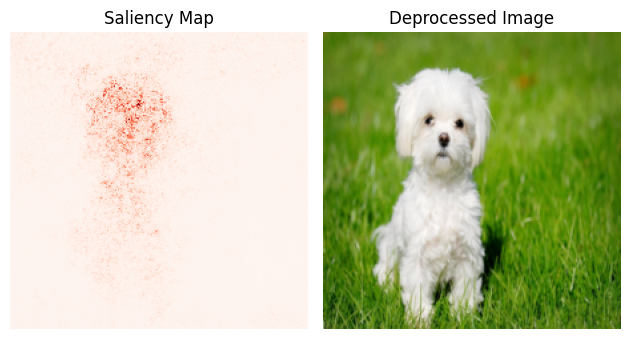

In [14]:
# Saliency map
plt.subplot(1, 2, 1)
plt.imshow(saliency[0], cmap='Reds')
plt.axis('off')
plt.title('Saliency Map')

# Imágen original
plt.subplot(1, 2, 2)
plt.imshow(deprocess(X.detach()))
plt.axis('off')
plt.title('Deprocessed Image')

# Espaciado
plt.tight_layout()

# Figura combinada
plt.show()